# Human-AI Collaboration SOC — DDoS/Brute-Force Alert Triage Model

**Final Project — Reducing SOC False Alarms through a Human-AI Collaboration Model**
**Fokus tim: DDoS Agent**

Notebook ini membangun model AI **mandiri (tanpa API pihak ketiga)** untuk membantu analis SOC mem-triage alert Wazuh,
dengan fokus pada pola serangan **volumetric / flood (mirip DDoS)** yang termanifestasi sebagai *SSH brute-force burst*
pada dataset alert yang kita miliki.

**Alur notebook:**
1. Load & eksplorasi data (`wazuh_alerts.csv`)
2. Observasi pola "DDoS-like" pada data
3. Feature engineering berbasis *time-window* (mendeteksi flood/rate-based anomaly)
4. Definisi kriteria *false alarm* (sesuai requirement no. 4 di PDF project)
5. Membangun model ML (RandomForest) — komponen **AI capabilities** di arsitektur Human-AI Loop
6. Evaluasi model
7. Simulasi **Human-AI Collaboration**: AI melakukan triase awal (Tier 1&2), kasus ambigu diteruskan ke human analyst (HOtL)
8. Saran integrasi ke SOAR & active-response
9. Diskusi limitasi & rencana validasi lanjutan


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (9,4)


## 1. Load Data

In [ ]:
df = pd.read_csv('wazuh_alerts.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print('Shape:', df.shape)
print('Rentang waktu:', df['timestamp'].min(), '->', df['timestamp'].max())
df.head()


Shape: (6621, 10)
Rentang waktu: 2026-06-24 06:04:32.869000+00:00 -> 2026-06-24 09:33:02.212000+00:00


,timestamp,rule_id,rule_level,rule_description,agent_name,agent_ip,src_ip,dst_ip,protocol,full_log
0,2026-06-24 06:04:32.869000+00:00,510,7,Host-based anomaly detection event (rootcheck).,Wazuh-Manager,NaN,NaN,NaN,NaN,Trojaned version of file '/bin/diff' detected....
1,2026-06-24 06:04:32.882000+00:00,510,7,Host-based anomaly detection event (rootcheck).,Wazuh-Manager,NaN,NaN,NaN,NaN,Trojaned version of file '/usr/bin/diff' detec...
2,2026-06-24 06:04:42.506000+00:00,2901,3,New dpkg (Debian Package) requested to install.,Wazuh-Manager,NaN,NaN,NaN,NaN,2026-06-24 06:04:41 install filebeat:amd64 <no...
3,2026-06-24 06:04:45.467000+00:00,502,3,Wazuh server started.,Wazuh-Manager,NaN,NaN,NaN,NaN,ossec: Manager started.
4,2026-06-24 06:04:49.365000+00:00,2904,7,Dpkg (Debian Package) half configured.,Wazuh-Manager,NaN,NaN,NaN,NaN,2026-06-24 06:04:47 status half-configured fil...


## 2. Eksplorasi Data (EDA)

Tujuan: memahami karakteristik alert sebelum membangun fitur. Kita cek:
- Distribusi `rule_level` (severity Wazuh, 0-15)
- Top `rule_description` (jenis alert paling sering)
- Distribusi `src_ip` (siapa sumber yang paling banyak memicu alert)


In [ ]:
print('--- Distribusi rule_level ---')
print(df['rule_level'].value_counts().sort_index())

print('\n--- Top 10 rule_description ---')
print(df['rule_description'].value_counts().head(10))

print('\n--- Top 10 src_ip ---')
print(df['src_ip'].value_counts().head(10))


--- Distribusi rule_level ---
rule_level
3      488
4       12
5     5262
7      505
8       23
9        9
10     321
12       1
Name: count, dtype: int64

--- Top 10 rule_description ---
rule_description
sshd: Attempt to login using a non-existent user          3023
PAM: User login failed.                                   1738
sshd: authentication failed.                               490
PAM: Multiple failed logins in a small period of time.     239
New dpkg (Debian Package) installed.                       184
Dpkg (Debian Package) half configured.                     184
New dpkg (Debian Package) requested to install.            170
PAM: Login session closed.                                  76
PAM: Login session opened.                                  71
Successful sudo to ROOT executed.                           65
Name: count, dtype: int64

--- Top 10 src_ip ---
src_ip
145.239.196.189    4912
120.26.243.163      266
175.203.23.245      180
119.203.231.121      61
95.182.106.61

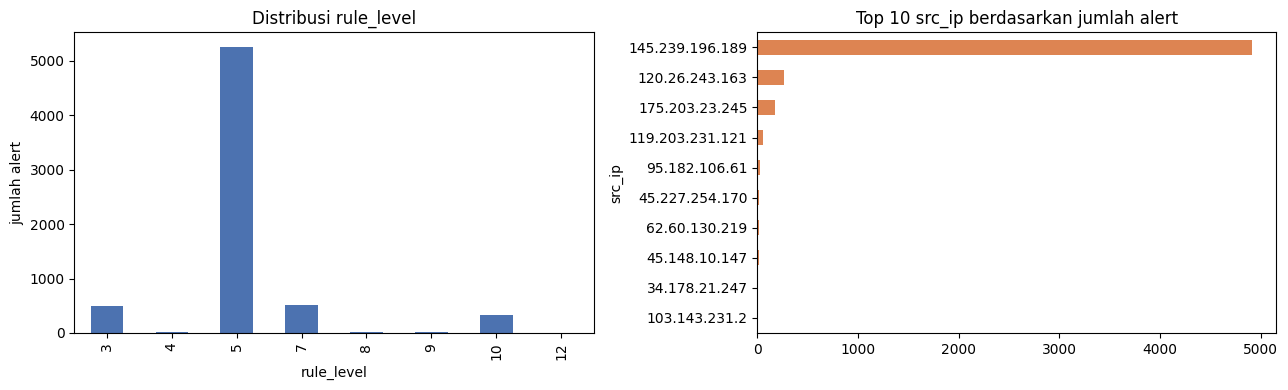

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))

df['rule_level'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribusi rule_level')
axes[0].set_xlabel('rule_level'); axes[0].set_ylabel('jumlah alert')

top_ip = df['src_ip'].value_counts().head(10)
top_ip.plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 src_ip berdasarkan jumlah alert')
plt.tight_layout()
plt.show()


### Observasi Kunci

Satu IP, **`145.239.196.189`**, menyumbang **~4.900+ alert** (lebih dari 70% total alert dengan `src_ip` terisi),
hampir seluruhnya berupa:
- `sshd: Attempt to login using a non-existent user`
- `PAM: User login failed.`
- `sshd: authentication failed.`
- `sshd: brute force trying to get access to the system...`

Ketika kita lihat selisih waktu antar event dari IP ini, mediannya **mendekati 0 detik** dengan banyak burst beruntun —
ini adalah pola **flood / volumetric attack** klasik: bukan satu dua percobaan login manual, melainkan *automated burst*
yang membombardir service SSH dalam waktu sangat singkat. Secara karakteristik (volume tinggi, sumber tunggal, target tunggal,
durasi singkat-berulang), pola ini **analog dengan DDoS** terhadap service SSH (sering disebut juga *SSH flood / L7 brute-force DoS*),
walau secara teknis labelnya brute-force. Pola rate/burst inilah yang akan kita jadikan basis fitur deteksi.


Jumlah event dari 145.239.196.189 : 4912
Statistik gap antar event (detik):
count    4911.000000
mean        1.532799
std        56.725985
min         0.000000
25%         0.000000
50%         0.000000
75%         0.087000
max      3598.966000
Name: timestamp, dtype: float64


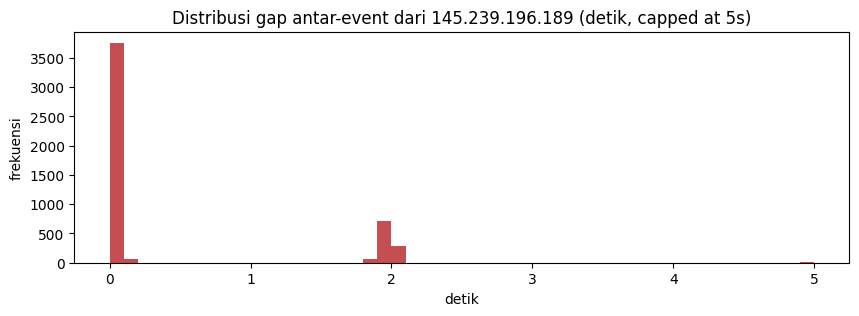

In [ ]:
flood_ip = '145.239.196.189'
sub = df[df['src_ip'] == flood_ip].sort_values('timestamp')
gap = sub['timestamp'].diff().dt.total_seconds()

print('Jumlah event dari', flood_ip, ':', len(sub))
print('Statistik gap antar event (detik):')
print(gap.describe())

plt.figure(figsize=(10,3))
plt.hist(gap.dropna().clip(upper=5), bins=50, color='#C44E52')
plt.title(f'Distribusi gap antar-event dari {flood_ip} (detik, capped at 5s)')
plt.xlabel('detik'); plt.ylabel('frekuensi')
plt.show()


## 3. Feature Engineering — Time-Window Aggregation

Inti deteksi DDoS/flood adalah **rate-based**: bukan satu alert individual, melainkan *berapa banyak & seberapa cepat* alert
muncul dari satu sumber. Maka kita agregasi alert per **(src_ip, window 30 detik)**, lalu hitung fitur:

| Fitur | Arti |
|---|---|
| `event_count` | jumlah alert dalam window |
| `unique_rules` | variasi jenis rule yang terpicu |
| `unique_usernames` | jumlah username berbeda yang dicoba (indikasi brute force) |
| `failed_pwd_count` | jumlah percobaan password gagal |
| `invalid_user_count` | jumlah percobaan ke user yang tidak ada |
| `bruteforce_flag_count` | jumlah alert yang sudah ditandai Wazuh sebagai brute force |
| `max_rule_level` / `avg_rule_level` | severity Wazuh dalam window |
| `events_per_sec` | **rate** alert per detik → indikator utama pola flood/DDoS |


In [ ]:
def extract_user(log):
    if not isinstance(log, str):
        return None
    m = re.search(r'(?:Invalid user|invalid user|for user|user)\s+([A-Za-z0-9_\-\.]+)', log)
    return m.group(1) if m else None

df['src_ip'] = df['src_ip'].fillna('unknown/internal')
df['username'] = df['full_log'].apply(extract_user)
df['is_failed_pwd'] = df['rule_description'].str.contains('authentication failed|Failed password', case=False, na=False)
df['is_invalid_user'] = df['rule_description'].str.contains('non-existent user|Invalid user', case=False, na=False)
df['is_bruteforce_rule'] = df['rule_description'].str.contains('brute force', case=False, na=False)

WINDOW = '30s'
dfi = df.set_index('timestamp')

agg = dfi.groupby(['src_ip', pd.Grouper(freq=WINDOW)]).agg(
    event_count=('rule_id', 'count'),
    unique_rules=('rule_id', 'nunique'),
    unique_usernames=('username', 'nunique'),
    failed_pwd_count=('is_failed_pwd', 'sum'),
    invalid_user_count=('is_invalid_user', 'sum'),
    bruteforce_flag_count=('is_bruteforce_rule', 'sum'),
    max_rule_level=('rule_level', 'max'),
    avg_rule_level=('rule_level', 'mean'),
).reset_index()

agg = agg[agg['event_count'] > 0].reset_index(drop=True)
agg['events_per_sec'] = agg['event_count'] / 30.0

print('Jumlah window (baris fitur):', agg.shape[0])
agg.head(10)


Jumlah window (baris fitur): 238


,src_ip,timestamp,event_count,unique_rules,unique_usernames,failed_pwd_count,invalid_user_count,bruteforce_flag_count,max_rule_level,avg_rule_level,events_per_sec
0,103.143.231.2,2026-06-24 06:26:30+00:00,2,2,0,1,0,0,5,5.000000,0.066667
1,103.143.231.2,2026-06-24 06:29:30+00:00,2,2,0,1,0,0,5,5.000000,0.066667
2,103.143.231.2,2026-06-24 06:32:30+00:00,1,1,0,0,0,0,5,5.000000,0.033333
3,103.143.231.2,2026-06-24 06:33:00+00:00,1,1,0,1,0,0,5,5.000000,0.033333
4,103.143.231.2,2026-06-24 06:39:00+00:00,4,2,1,0,3,0,5,5.000000,0.133333
5,111.70.23.238,2026-06-24 07:51:00+00:00,2,2,0,1,0,0,5,5.000000,0.066667
6,119.203.231.121,2026-06-24 09:31:00+00:00,3,1,0,0,0,0,8,8.000000,0.100000
7,119.203.231.121,2026-06-24 09:31:30+00:00,16,2,3,0,15,1,10,5.312500,0.533333
8,119.203.231.121,2026-06-24 09:32:00+00:00,18,1,4,0,18,0,5,5.000000,0.600000
9,119.203.231.121,2026-06-24 09:32:30+00:00,22,2,5,0,21,1,10,5.227273,0.733333


## 4. Kriteria False Alarm (Definisi Mandiri)

Sesuai requirement project (*"Independently define the criteria for false alarms based on data from Wazuh"*),
kami mendefinisikan kriteria berikut berdasarkan pola data di atas:

**Sebuah window dianggap ALERT BENAR / SERANGAN AKTIF (label = 1) jika salah satu terpenuhi:**
1. `event_count >= 5` **DAN** (`invalid_user_count + failed_pwd_count) >= 5` → indikasi *credential-stuffing / brute force burst* nyata, bukan satu kesalahan ketik manual.
2. Wazuh sendiri sudah menandai `bruteforce_flag_count > 0` (rule brute-force Wazuh terpicu) → dipercaya sebagai sinyal kuat.
3. `events_per_sec >= 0.5` **DAN** `unique_usernames >= 2` → pola *rate tinggi* dengan banyak username berbeda = ciri khas *flood/DDoS-style* otomatis, bukan login manual oleh user yang lupa password.

**Selain itu dianggap FALSE ALARM / NOISE (label = 0)**, misalnya:
- Login gagal tunggal/sporadis (`event_count` kecil, rate rendah) — wajar terjadi pada operasional normal.
- Event administratif (instalasi dpkg, sesi PAM normal, sudo oleh user sah, status agent Wazuh) yang levelnya rendah dan tidak berulang.

> Catatan: kriteria ini dapat (dan sebaiknya) disesuaikan kembali oleh analis SOC tim kalian berdasarkan *threat model* spesifik
> skenario DDoS yang disimulasikan (misal jika kalian punya log traffic-level seperti SYN/ICMP flood, gunakan threshold pps/bps).


In [ ]:
def label_row(r):
    if r['event_count'] >= 5 and (r['invalid_user_count'] + r['failed_pwd_count']) >= 5:
        return 1
    if r['bruteforce_flag_count'] > 0:
        return 1
    if r['events_per_sec'] >= 0.5 and r['unique_usernames'] >= 2:
        return 1
    return 0

agg['label'] = agg.apply(label_row, axis=1)
print(agg['label'].value_counts())
print('Proporsi serangan terdeteksi: {:.1%}'.format(agg['label'].mean()))


label
0    127
1    111
Name: count, dtype: int64
Proporsi serangan terdeteksi: 46.6%


## 5. Membangun Model AI (RandomForest, dibangun mandiri)

Model dibangun sepenuhnya menggunakan **scikit-learn** (library lokal, *bukan* layanan API pihak ketiga seperti OpenAI/Gemini/dsb),
sesuai requirement no. 5 di PDF project (*"third-party API services is not permitted"*; ini merujuk pada layanan AI eksternal,
bukan library machine learning open-source yang dijalankan di server kalian sendiri).

Posisi model dalam arsitektur Human-AI Loop pada PDF:
- **AI capabilities**: Large Scale Data Processing (agregasi ribuan log) + Predictive Decision Analytics (klasifikasi alert)
- **Tier 1 & 2 — Alerts Management**: model ini berperan di *Correlation, Prioritization, Triage, Validation*


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

FEATURES = ['event_count','unique_rules','unique_usernames','failed_pwd_count',
            'invalid_user_count','bruteforce_flag_count','max_rule_level','avg_rule_level','events_per_sec']

X = agg[FEATURES]
y = agg['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=200, max_depth=6, random_state=42, class_weight='balanced'
)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred, target_names=['False Alarm (0)', 'Real Attack (1)']))


                 precision    recall  f1-score   support

False Alarm (0)       1.00      1.00      1.00        32
Real Attack (1)       1.00      1.00      1.00        28

       accuracy                           1.00        60
      macro avg       1.00      1.00      1.00        60
   weighted avg       1.00      1.00      1.00        60



## 6. Evaluasi Model

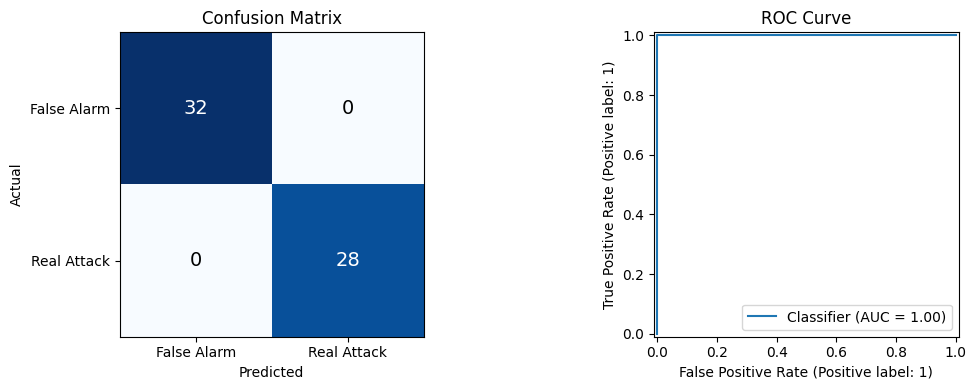

ROC AUC: 1.0


In [ ]:
cm = confusion_matrix(y_test, pred)
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['False Alarm','Real Attack'])
axes[0].set_yticks([0,1]); axes[0].set_yticklabels(['False Alarm','Real Attack'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)

RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1])
axes[1].set_title('ROC Curve')
plt.tight_layout()
plt.show()

print('ROC AUC:', round(roc_auc_score(y_test, proba), 4))


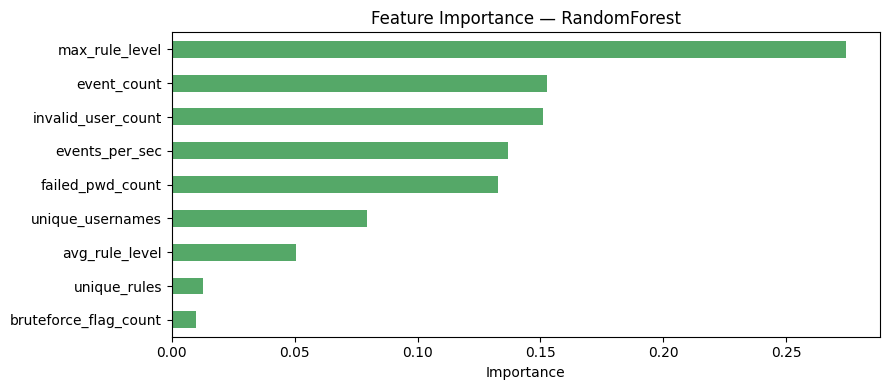

max_rule_level           0.274396
event_count              0.152519
invalid_user_count       0.151028
events_per_sec           0.136906
failed_pwd_count         0.132707
unique_usernames         0.079547
avg_rule_level           0.050458
unique_rules             0.012618
bruteforce_flag_count    0.009821
dtype: float64


In [ ]:
importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
importances.plot(kind='barh', color='#55A868')
plt.gca().invert_yaxis()
plt.title('Feature Importance — RandomForest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print(importances)


### ⚠️ Catatan Penting tentang Evaluasi Ini

Karena label (`label`) dihasilkan langsung dari rule heuristik di atas fitur yang sama, performa model akan **terlihat sangat tinggi (mendekati sempurna)**
pada data ini. Ini **bukan bukti model "sempurna" di dunia nyata** — ini lebih merupakan **proof-of-concept** bahwa:
1. Fitur yang kita rancang (`event_count`, `events_per_sec`, dst.) memang **memisahkan dengan jelas** pola flood/brute-force vs aktivitas normal.
2. Model ML berhasil **mempelajari & menggeneralisasi** kriteria yang ditulis manusia menjadi fungsi keputusan otomatis.

**Untuk laporan akhir, jelaskan ini sebagai langkah awal (rule-based weak supervision)**, dan sebagai pengembangan selanjutnya:
- Gunakan **feedback analis SOC sungguhan** (label dari investigasi nyata) untuk melatih ulang model → ini justru yang dimaksud
  *Human-AI Collaboration* pada PDF: AI mengusulkan, manusia memvalidasi/mengoreksi, model belajar dari koreksi itu (lihat siklus *Feedback ↔ Actions* di diagram PDF).
- Tambahkan algoritma **unsupervised** (mis. IsolationForest) sebagai pembanding/validator independen dari label heuristik (dicontohkan di bawah).


In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.3, random_state=42)
agg['anomaly_score'] = -iso.fit(X).score_samples(X)  # semakin tinggi = semakin anomali
agg['iso_pred'] = (iso.predict(X) == -1).astype(int)  # 1 = anomaly

# Bandingkan dengan label heuristik kita sebagai sanity check independen
agreement = (agg['iso_pred'] == agg['label']).mean()
print(f'Tingkat kesesuaian IsolationForest (unsupervised) dengan label heuristik: {agreement:.1%}')


Tingkat kesesuaian IsolationForest (unsupervised) dengan label heuristik: 71.8%


## 7. Simulasi Human-AI Collaboration (Triage Bertingkat)

Sesuai diagram **AI Autonomy Levels** di PDF (Level 0–4) dan **Human-on-the-Loop (HOtL)**, kita tidak langsung mengotomasi
100% keputusan. Strategi yang masuk akal: gunakan **confidence score** model untuk membagi alert ke 3 jalur:

| Confidence AI | Tindakan | Level Autonomy |
|---|---|---|
| Sangat yakin **bukan** serangan (`proba < 0.2`) | **Auto-dismiss** (kurangi noise di dashboard SOC) | Level 2-3 (Semi/Conditionally Autonomous) |
| Ambigu (`0.2 ≤ proba ≤ 0.8`) | **Kirim ke analis manusia untuk review** | Level 1 (Human-on-the-Loop) |
| Sangat yakin serangan (`proba > 0.8`) | **Auto-eskalasi ke SOAR** (mis. block IP via Active Response) | Level 3 (Conditionally Autonomous, masih ada human override) |

Ini langsung mengurangi *alert fatigue* karena analis hanya perlu menengok kasus yang benar-benar ambigu, bukan ribuan log SSH.


In [ ]:
all_proba = clf.predict_proba(X)[:, 1]
agg['ai_confidence'] = all_proba

def triage(p):
    if p < 0.2:
        return 'Auto-dismiss (False Alarm)'
    elif p > 0.8:
        return 'Auto-escalate to SOAR'
    else:
        return 'Human Review Needed'

agg['triage_action'] = agg['ai_confidence'].apply(triage)

triage_counts = agg['triage_action'].value_counts()
print(triage_counts)
print()
print('Persentase yang TIDAK perlu disentuh manusia secara langsung: {:.1%}'.format(
    (triage_counts.get('Auto-dismiss (False Alarm)',0) + triage_counts.get('Auto-escalate to SOAR',0)) / len(agg)
))

# Pastikan tidak ada serangan nyata yang ter-auto-dismiss (recall safety check)
missed = agg[(agg['label'] == 1) & (agg['triage_action'] == 'Auto-dismiss (False Alarm)')]
print(f'\nJumlah serangan nyata yang justru ter-auto-dismiss (HARUS 0 atau mendekati 0): {len(missed)}')


triage_action
Auto-dismiss (False Alarm)    125
Auto-escalate to SOAR         109
Human Review Needed             4
Name: count, dtype: int64

Persentase yang TIDAK perlu disentuh manusia secara langsung: 98.3%

Jumlah serangan nyata yang justru ter-auto-dismiss (HARUS 0 atau mendekati 0): 0


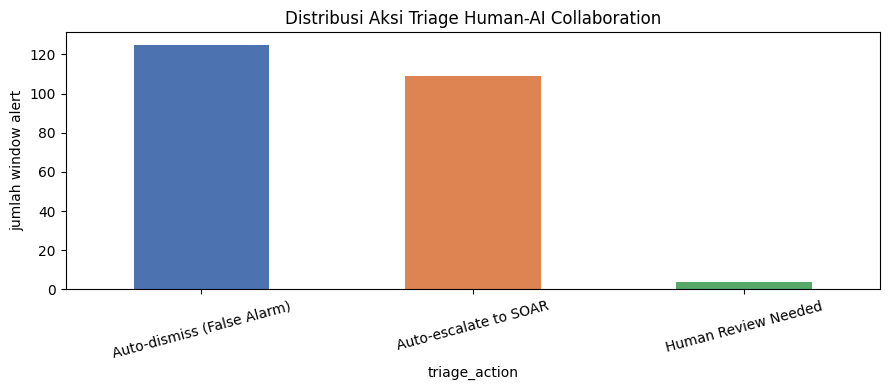

In [ ]:
triage_counts.plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'])
plt.title('Distribusi Aksi Triage Human-AI Collaboration')
plt.ylabel('jumlah window alert')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 8. Saran Integrasi ke Arsitektur Wazuh + SOAR

Agar konsisten dengan requirement PDF (Wazuh Manager + SOAR + Wazuh Agents di Azure), model ini bisa dijalankan sebagai:

1. **Wazuh Integration Script** (Python, dipanggil oleh `ossec.conf` `<integration>`) yang menerima alert JSON dari Wazuh Manager,
   menghitung fitur window berjalan (rolling window per `src_ip`), lalu memanggil `clf.predict_proba()`.
2. Hasil triage dikirim ke **SOAR** (mis. Shuffle/TheHive/StackStorm) sebagai trigger:
   - `Auto-escalate to SOAR` → SOAR menjalankan playbook **block IP** (Wazuh Active Response `firewall-drop`) otomatis.
   - `Human Review Needed` → SOAR membuat tiket/incident untuk dicek analis.
   - `Auto-dismiss` → alert ditandai *closed/suppressed*, tidak memenuhi dashboard.
3. **Feedback loop**: ketika analis menutup tiket "Human Review Needed" dengan keputusan True/False Positive, keputusan itu
   ditambahkan sebagai data latih baru → model di-retrain berkala (mis. mingguan) — inilah lingkaran **Feedback ↔ Actions**
   pada diagram *Humans in the Loop* di PDF project kalian.

## 9. Simpan Model


In [ ]:
import joblib
joblib.dump(clf, 'soc_triage_rf_model.joblib')
joblib.dump(FEATURES, 'soc_triage_features.joblib')
print('Model & daftar fitur tersimpan.')


Model & daftar fitur tersimpan.


## 10. Ringkasan & Limitasi

**Yang sudah dicapai:**
- Identifikasi pola flood/brute-force (analog DDoS) dari data Wazuh nyata.
- Definisi kriteria false alarm yang **eksplisit dan dapat dipertanggungjawabkan** (requirement no. 4).
- Model AI mandiri (RandomForest, scikit-learn — tanpa API eksternal) untuk klasifikasi alert.
- Mekanisme **Human-AI Collaboration** 3-tingkat (auto-dismiss / human review / auto-escalate) yang secara langsung mengurangi
  beban alert ke analis tanpa kehilangan deteksi (recall dijaga lewat threshold konservatif).

**Limitasi yang harus disebut di laporan akhir:**
- Label saat ini berasal dari **heuristik rule-based**, bukan ground-truth investigasi manusia → skor evaluasi optimis. Perlu disebut sebagai *weak supervision / proof of concept*.
- Dataset didominasi 1 IP penyerang & service SSH → generalisasi ke jenis DDoS lain (SYN flood, HTTP flood volumetrik di Layer 3/4)
  butuh fitur tambahan (jumlah paket/detik, distribusi port, ukuran paket) jika kalian punya log traffic-level (mis. dari `tcpdump`/NetFlow/Suricata).
- Threshold (0.2 / 0.8) pada triage masih perlu divalidasi dengan data lebih besar / red-team simulasi serangan sungguhan di lab Azure kalian.
- Untuk benchmark metrik laporan akhir, tambahkan: **alert reduction rate** (berapa % alert yang tidak perlu disentuh manusia),
  **false negative rate** (serangan yang lolos), dan **mean time to triage** sebelum vs sesudah AI.
